# Dataset Analysis & Incorrect Label Review
Visualizes behavior distributions and highlights mislabelled examples across train/test splits.

In [1]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
DATASET_CSV      = "/fs/vulcan-projects/fsh_track/processed_data/dataset6/dataset6.csv"
DUPLICATES_CSV   = "/fs/vulcan-projects/fsh_track/will/old/bad_video_exp/bad_videos.csv" 

FILTER_ONE_BEHAVIORS = ["Peck", "Quiver", "Lead", "Bite", "Tilt", "Run/Flee"]

C_TYPE_MASTERS = [
    "60min.mp4",
    "080225_spawn_B1-5.mp4",
    "090625_K1-2_spawn.mp4",
    "091625_spawn_K1-2 (1).mp4",
]
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import os

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0f1117",
    "axes.facecolor":    "#1a1d27",
    "axes.edgecolor":    "#2e3248",
    "axes.labelcolor":   "#c8cde0",
    "axes.titlecolor":   "#e8ecf5",
    "xtick.color":       "#8890aa",
    "ytick.color":       "#8890aa",
    "text.color":        "#c8cde0",
    "grid.color":        "#2e3248",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "monospace",
    "axes.titlesize":    14,
    "axes.labelsize":    11,
})

TRAIN_COLOR = "#4f8ef7"   # blue
TEST_COLOR  = "#f7724f"   # coral
BAD_COLOR   = "#f7c44f"   # amber

print("Imports OK")

Imports OK


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(DATASET_CSV)
dupes = pd.read_csv(DUPLICATES_CSV)

# Normalise split labels to lowercase for safety
df["split"] = df["split"].str.lower().str.strip()

# Extract clip stem (filename without extension) from video_path
df["clip_stem"] = df["video_path"].apply(
    lambda p: os.path.splitext(os.path.basename(p))[0]
)

# Normalise duplicate strings
dupes["string"] = dupes["string"].str.strip()

print(f"Dataset rows   : {len(df):,}")
print(f"Behaviors found: {sorted(df['behavior'].unique())}")
print(f"Splits found   : {sorted(df['split'].unique())}")
print(f"Duplicate stems: {len(dupes):,}")
df.head(3)

Dataset rows   : 2,515
Behaviors found: ['Bite', 'Chase/Charge', 'Circling', 'Egg Retrieval', 'Enter Pot', 'Exit Plot', 'Follow', 'Lead', 'Peck', 'Quiver', 'Run/Flee', 'Spawning', 'Tilt']
Splits found   : ['test', 'train']
Duplicate stems: 259


,video_path,behavior,og_behavior,start_time,end_time,master_video,duration,dataset,split,clip_stem
0,/fs/vulcan-projects/fsh_track/processed_data/d...,Quiver,male quiver,45.300,49.300,080225_spawn_B1-5.mp4,4.0,fshdata,train,080225_spawn_B1-5_clip1
1,/fs/vulcan-projects/fsh_track/processed_data/d...,Enter Pot,pot entry,128.067,132.067,080225_spawn_B1-5.mp4,4.0,fshdata,train,080225_spawn_B1-5_clip2
2,/fs/vulcan-projects/fsh_track/processed_data/d...,Exit Plot,exit plot,129.500,133.500,080225_spawn_B1-5.mp4,4.0,fshdata,train,080225_spawn_B1-5_clip3


In [4]:
def assign_segments(group):
    seg = 0
    segments = []
    prev_start = -1
    for start in group["start_time"]:
        if start < prev_start:
            seg += 1
        segments.append(seg)
        prev_start = start
    return pd.Series(segments, index=group.index)

df["_seg"] = df.groupby("master_video", group_keys=False).apply(assign_segments)

max_seg = df.groupby("master_video")["_seg"].max()

def make_mv_id(row):
    base, ext = os.path.splitext(row["master_video"])
    if max_seg[row["master_video"]] == 0:
        return row["master_video"]
    return f"{base}_seg{row['_seg']}{ext}"

df["master_video_id"] = df.apply(make_mv_id, axis=1)
df.drop(columns=["_seg"], inplace=True)

/tmp/ipykernel_3428124/681948044.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["_seg"] = df.groupby("master_video", group_keys=False).apply(assign_segments)


In [5]:
# ── Helper: stacked bar chart ──────────────────────────────────────────────────
def stacked_behavior_bar(data: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    """
    Draw a stacked bar of train/test clip counts per behavior.
    `data` must have columns: behavior, split.
    """
    pivot = (
        data.groupby(["behavior", "split"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=["train", "test"], fill_value=0)
    )
    # Sort by total descending
    pivot = pivot.loc[(pivot["train"] + pivot["test"]).sort_values(ascending=False).index]

    behaviors = pivot.index.tolist()
    x = np.arange(len(behaviors))
    width = 0.6

    bars_train = ax.bar(x, pivot["train"], width, label="Train", color=TRAIN_COLOR, zorder=3)
    bars_test  = ax.bar(x, pivot["test"],  width, label="Test",
                        bottom=pivot["train"], color=TEST_COLOR, zorder=3)

    # Total labels on top
    totals = pivot["train"] + pivot["test"]
    for xi, total in zip(x, totals):
        ax.text(xi, total + totals.max() * 0.01, f"{total:,}",
                ha="center", va="bottom", fontsize=8, color="#e8ecf5")

    ax.set_xticks(x)
    ax.set_xticklabels(behaviors, rotation=35, ha="right", fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylabel("Clip count")
    ax.set_title(title, pad=12)
    ax.legend(framealpha=0.3, fontsize=9)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    # Spine cleanup
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

print("Helper defined")

Helper defined


## Figure 1 — All behaviors (train / test split)

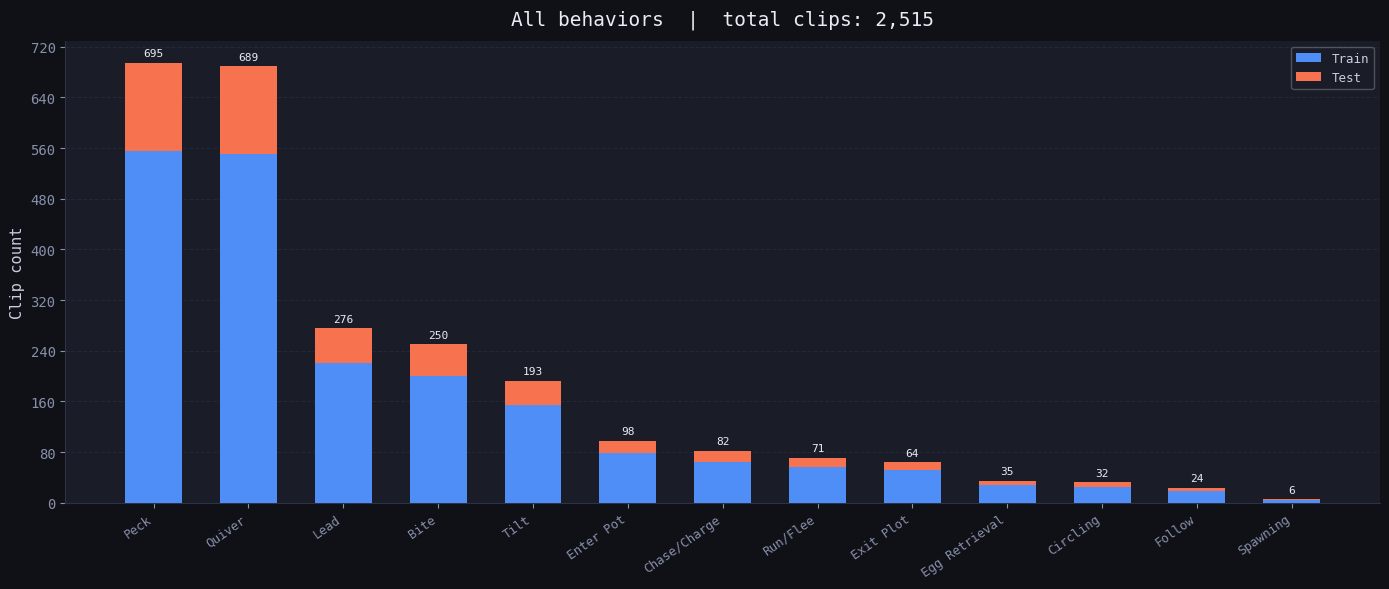

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
stacked_behavior_bar(df, f"All behaviors  |  total clips: {len(df):,}", ax)
fig.tight_layout()
#plt.savefig("fig1_all_behaviors.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 — Filtered behaviors only

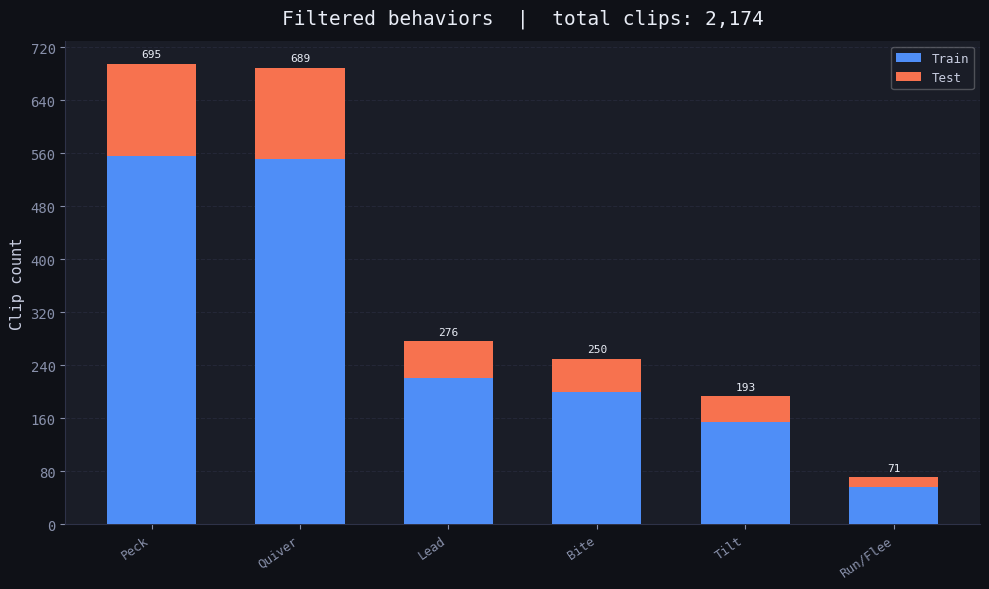

In [ ]:
df_filtered = df[df["behavior"].isin(FILTER_ONE_BEHAVIORS)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
stacked_behavior_bar(
    df_filtered,
    f"Filtered behaviors  |  total clips: {len(df_filtered):,}",
    ax
)
fig.tight_layout()
#plt.savefig("fig2_filtered_behaviors.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 — Incorrectly labelled clips by behavior

In [8]:
# Match duplicate stems back to the dataset
df_bad = df[df["clip_stem"].isin(dupes["string"])].copy()

print(f"Incorrect clips matched in dataset : {len(df_bad):,}")
unmatched = set(dupes["string"]) - set(df["clip_stem"])
if unmatched:
    print(f"Unmatched stems (not in dataset)   : {len(unmatched)}")
    for s in sorted(unmatched)[:10]:
        print(f"  {s}")
    if len(unmatched) > 10:
        print(f"  ... and {len(unmatched)-10} more")

Incorrect clips matched in dataset : 259


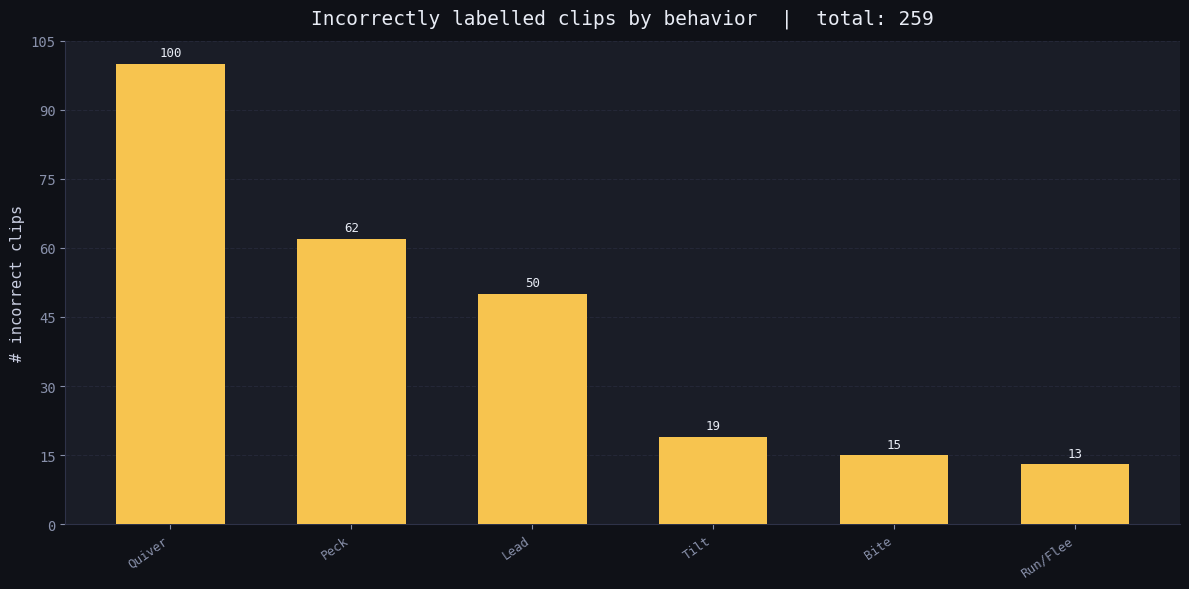

In [ ]:
bad_counts = (
    df_bad.groupby("behavior")
          .size()
          .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(bad_counts))
bars = ax.bar(x, bad_counts.values, color=BAD_COLOR, width=0.6, zorder=3)

# Value labels
for xi, val in zip(x, bad_counts.values):
    ax.text(xi, val + bad_counts.max() * 0.01, str(val),
            ha="center", va="bottom", fontsize=9, color="#e8ecf5")

ax.set_xticks(x)
ax.set_xticklabels(bad_counts.index, rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylabel("# incorrect clips")
ax.set_title(
    f"Incorrectly labelled clips by behavior  |  total: {len(df_bad):,}",
    pad=12
)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#plt.savefig("fig3_incorrect_by_behavior.png", dpi=150, bbox_inches="tight")
plt.show()

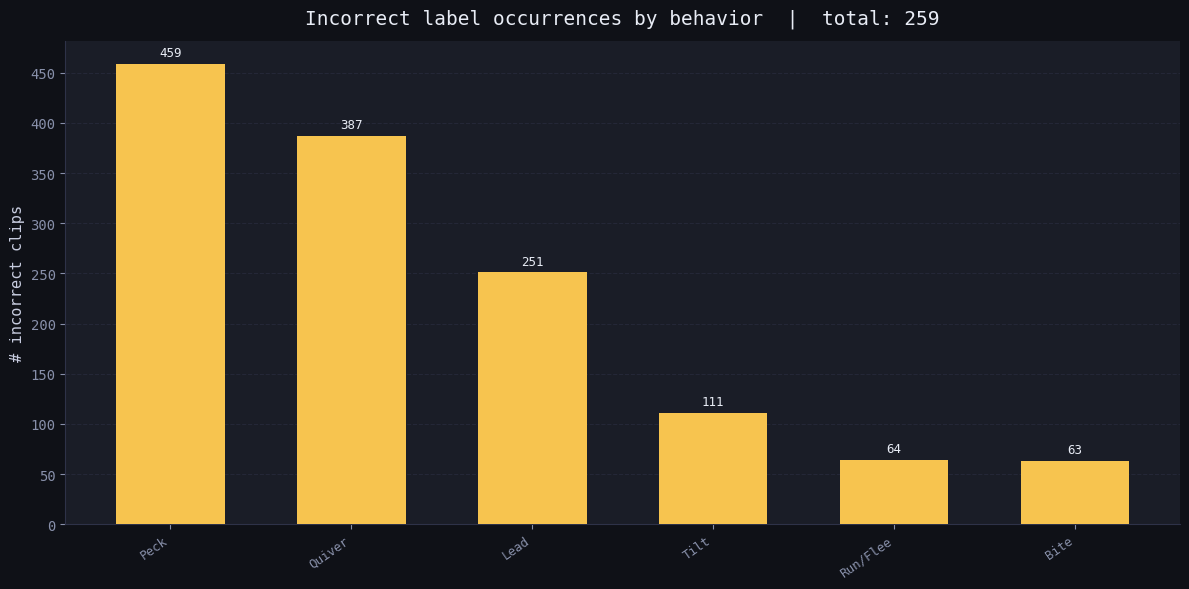

In [ ]:
#bad counts but totalled
# Join file_count from dupes onto df_bad
df_bad_weighted = df_bad.merge(
    dupes[["string", "file_count"]],
    left_on="clip_stem",
    right_on="string",
    how="left"
)

bad_counts_total = (
    df_bad_weighted.groupby("behavior")["file_count"]
                   .sum()
                   .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(bad_counts_total))
bars = ax.bar(x, bad_counts_total.values, color=BAD_COLOR, width=0.6, zorder=3)

# Value labels
for xi, val in zip(x, bad_counts_total.values):
    ax.text(xi, val + bad_counts_total.max() * 0.01, str(val),
            ha="center", va="bottom", fontsize=9, color="#e8ecf5")

ax.set_xticks(x)
ax.set_xticklabels(bad_counts_total.index, rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylabel("# incorrect clips")
ax.set_title(
    f"Incorrect label occurrences by behavior  |  total: {int(bad_counts.sum()):,}",
    pad=12
)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#plt.savefig("fig3TOTALLED_incorrect_by_behavior.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Tag every row with its video type
df["video_type"] = df["master_video"].apply(
    lambda m: "C" if m in C_TYPE_MASTERS else "J"
)

# Behaviour × video-type counts
type_behavior = (
    df.groupby(["video_type", "behavior"])
      .size()
      .unstack(fill_value=0)
)

print("Clip counts by video type:")
print(df["video_type"].value_counts().to_string())
print()
print("Behavior breakdown by video type:")
print(type_behavior.to_string())

Clip counts by video type:
video_type
C    1653
J     862

Behavior breakdown by video type:
behavior    Bite  Chase/Charge  Circling  Egg Retrieval  Enter Pot  Exit Plot  Follow  Lead  Peck  Quiver  Run/Flee  Spawning  Tilt
video_type                                                                                                                         
C            250            82        32             35         98         64      13   176   281     358        71         0   193
J              0             0         0              0          0          0      11   100   414     331         0         6     0


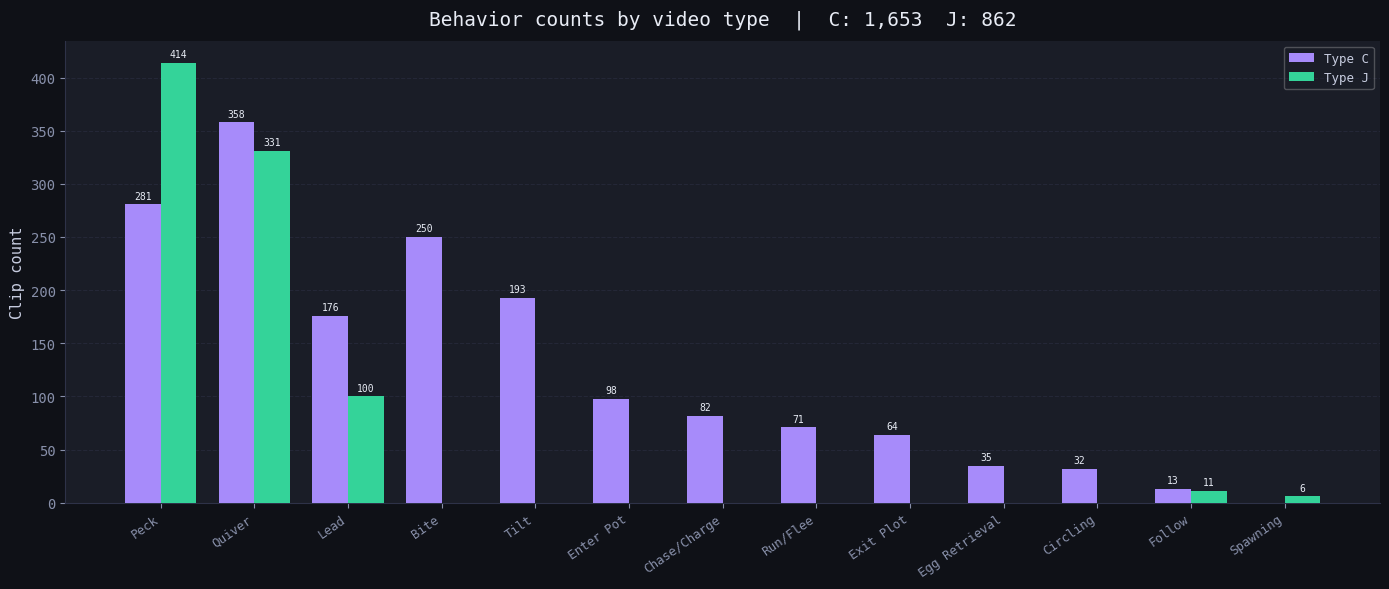

/tmp/ipykernel_3428124/3512705374.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_behaviors))


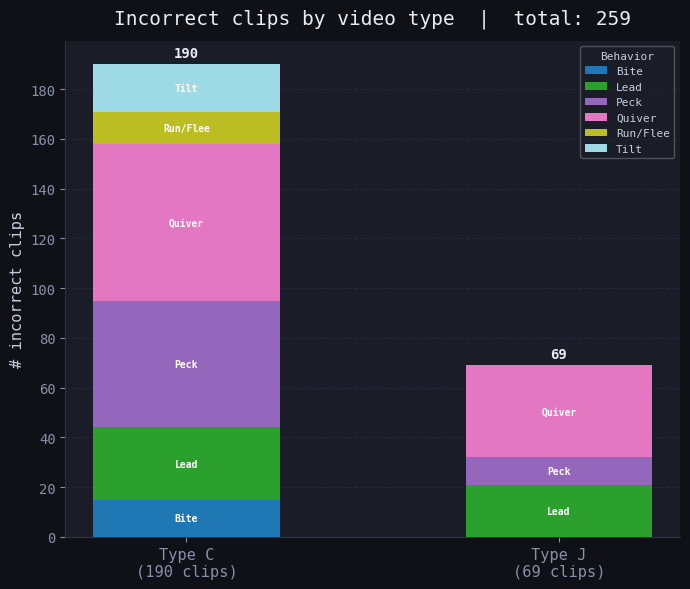

In [ ]:
pivot_type = (
    df.groupby(["behavior", "video_type"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=["C", "J"], fill_value=0)
)
# Sort by total descending
pivot_type = pivot_type.loc[
    (pivot_type["C"] + pivot_type["J"]).sort_values(ascending=False).index
]

behaviors = pivot_type.index.tolist()
x = np.arange(len(behaviors))
w = 0.38

C_COLOR = "#a78bfa"   # violet  — type C
J_COLOR = "#34d399"   # emerald — type J

fig, ax = plt.subplots(figsize=(14, 6))

bars_c = ax.bar(x - w/2, pivot_type["C"], w, label="Type C", color=C_COLOR, zorder=3)
bars_j = ax.bar(x + w/2, pivot_type["J"], w, label="Type J", color=J_COLOR, zorder=3)

# Value labels
for bars in (bars_c, bars_j):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + pivot_type.values.max() * 0.008,
                str(int(h)),
                ha="center", va="bottom", fontsize=7, color="#e8ecf5"
            )

ax.set_xticks(x)
ax.set_xticklabels(behaviors, rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylabel("Clip count")
ax.set_title(
    f"Behavior counts by video type  |  C: {int(pivot_type['C'].sum()):,}  J: {int(pivot_type['J'].sum()):,}",
    pad=12
)
ax.legend(framealpha=0.3, fontsize=9)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#plt.savefig("fig4_behaviors_by_type.png", dpi=150, bbox_inches="tight")
plt.show()


# ════════════════════════════════════════════════════════════════════════════════
# NEW CELL 3 — Figure 5: incorrect clips by video type (stacked by behavior)
# ════════════════════════════════════════════════════════════════════════════════

# df_bad was created in the Figure 3 cell — make sure that cell ran first
df_bad["video_type"] = df_bad["master_video"].apply(
    lambda m: "C" if m in C_TYPE_MASTERS else "J"
)

bad_type_beh = (
    df_bad.groupby(["video_type", "behavior"])
          .size()
          .unstack(fill_value=0)
)

# Use a colourmap for behaviors so stacked sections are distinguishable
all_behaviors = bad_type_beh.columns.tolist()
cmap = plt.cm.get_cmap("tab20", len(all_behaviors))
behavior_colors = {b: cmap(i) for i, b in enumerate(all_behaviors)}

fig, ax = plt.subplots(figsize=(7, 6))

video_types = bad_type_beh.index.tolist()   # ["C", "J"] or whichever exist
x = np.arange(len(video_types))
w = 0.5
bottoms = np.zeros(len(video_types))

for beh in all_behaviors:
    vals = bad_type_beh[beh].reindex(video_types, fill_value=0).values
    bars = ax.bar(x, vals, w, bottom=bottoms,
                  label=beh, color=behavior_colors[beh], zorder=3)
    # Label segments that are large enough to read
    for xi, (val, bot) in enumerate(zip(vals, bottoms)):
        if val > bad_type_beh.values.max() * 0.04:
            ax.text(
                xi, bot + val / 2, beh,
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold"
            )
    bottoms += vals

# Total on top
for xi, total in zip(x, bottoms):
    ax.text(xi, total + bad_type_beh.values.sum(axis=1).max() * 0.01,
            str(int(total)), ha="center", va="bottom",
            fontsize=10, color="#e8ecf5", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"Type {vt}\n({int(bad_type_beh.loc[vt].sum())} clips)" for vt in video_types],
    fontsize=11
)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylabel("# incorrect clips")
ax.set_title(
    f"Incorrect clips by video type  |  total: {len(df_bad):,}",
    pad=12
)
ax.legend(
    loc="upper right", framealpha=0.3,
    fontsize=8, title="Behavior", title_fontsize=8
)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#plt.savefig("fig5_incorrect_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

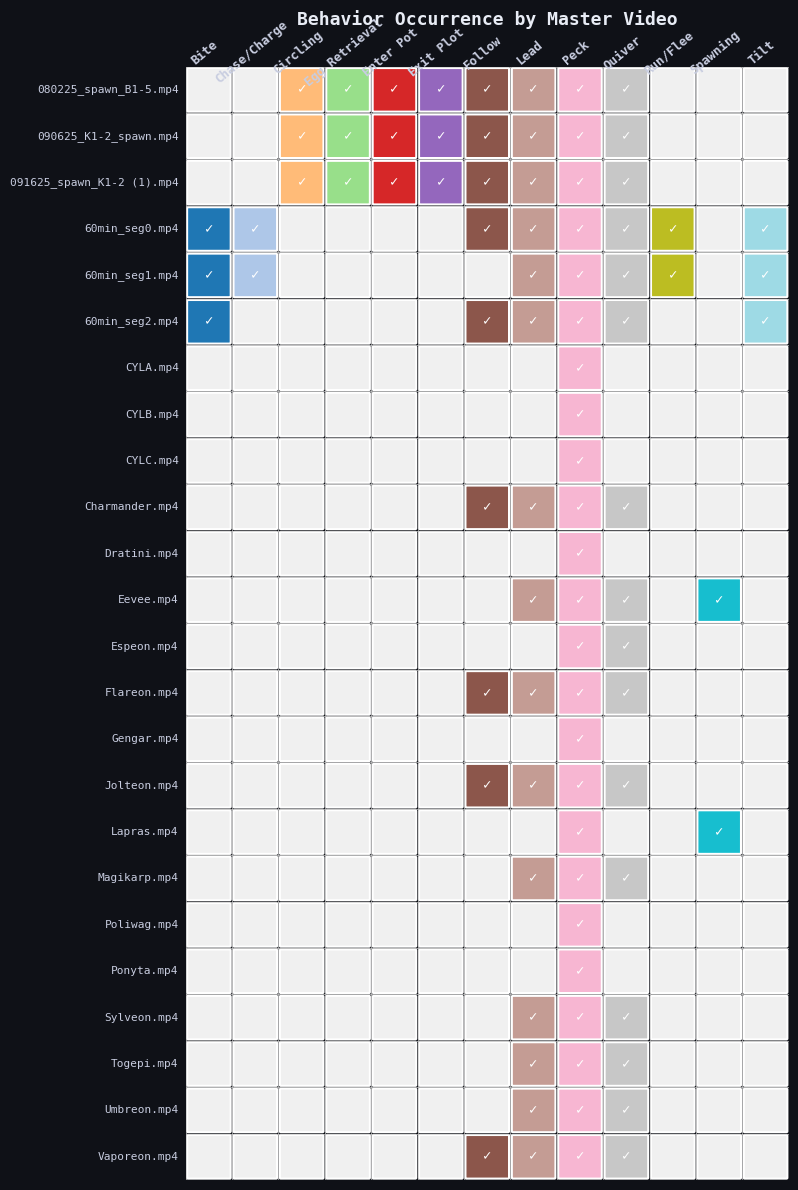


Matrix: 24 videos × 13 behaviors


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Build pivot: which behaviors occur in which master videos
pivot = df.groupby(['master_video_id', 'behavior']).size().unstack(fill_value=0)
pivot_bool = (pivot > 0).astype(int)

behaviors = pivot_bool.columns.tolist()
videos = pivot_bool.index.tolist()

n_rows = len(videos)
n_cols = len(behaviors)

fig, ax = plt.subplots(figsize=(max(10, n_cols * 1.1), max(4, n_rows * 0.5)))
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect('equal')
ax.axis('off')

# Color palette per behavior (cycles if many behaviors)
cmap = plt.get_cmap('tab20', n_cols)
behavior_colors = {b: cmap(i) for i, b in enumerate(behaviors)}

# Draw cells
for row_idx, video in enumerate(videos):
    y = n_rows - row_idx - 1  # top-to-bottom
    for col_idx, behavior in enumerate(behaviors):
        x = col_idx
        present = pivot_bool.loc[video, behavior]
        color = behavior_colors[behavior] if present else '#f0f0f0'
        rect = mpatches.FancyBboxPatch(
            (x + 0.05, y + 0.05), 0.9, 0.9,
            boxstyle="round,pad=0.02",
            facecolor=color,
            edgecolor='white', linewidth=1.5
        )
        ax.add_patch(rect)
        if present:
            ax.text(x + 0.5, y + 0.5, '✓', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')

# Column headers (behaviors) — rotated
for col_idx, behavior in enumerate(behaviors):
    ax.text(col_idx + 0.5, n_rows + 0.2, behavior,
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            rotation=40, rotation_mode='anchor')

# Row headers (master videos)
for row_idx, video in enumerate(videos):
    y = n_rows - row_idx - 1
    ax.text(-0.15, y + 0.5, video, ha='right', va='center', fontsize=8)

# Grid lines
for i in range(n_cols + 1):
    ax.axvline(i, color='#cccccc', linewidth=0.5)
for i in range(n_rows + 1):
    ax.axhline(i, color='#cccccc', linewidth=0.5)

plt.title('Behavior Occurrence by Master Video', fontsize=13, fontweight='bold', pad=30)
plt.tight_layout()
#plt.savefig('behavior_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMatrix: {n_rows} videos × {n_cols} behaviors")